In [56]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [57]:
DATA_PATH = Path("data/classification_bonus_practice_data.csv")

df = pd.read_csv(DATA_PATH)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Number of rows: 15000
Number of columns: 16


,ID,Survive,Gender,Smoke,Diabetes,Age,Ejection Fraction,Sodium,Creatinine,Platelets,Creatine phosphokinase,Blood Pressure,Hemoglobin,Height,Weight,Favorite color
0,TIG1GE,0,Male,Yes,Normal,50,Low,141,0.7,266000.0,185,105,12.3,180,93,green
1,VXUCV9,1,Male,No,Normal,75,Low,134,2.5,224000.0,99,162,13.0,140,47,black
2,AFH4F1,1,Female,No,Pre-diabetes,80,Low,135,1.3,192000.0,776,179,12.4,150,61,white
3,ZK6PAC,0,Male,No,Normal,-60,Low,136,0.9,228000.0,2261,136,15.3,130,48,yellow
4,6CVBRT,0,Female,No,Normal,70,Low,141,0.9,358000.0,1202,171,13.3,177,64,blue


In [58]:
df.columns.tolist()


['ID',
 'Survive',
 'Gender',
 'Smoke',
 'Diabetes',
 'Age',
 'Ejection Fraction',
 'Sodium',
 'Creatinine',
 'Platelets',
 'Creatine phosphokinase',
 'Blood Pressure',
 'Hemoglobin',
 'Height',
 'Weight',
 'Favorite color']

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      15000 non-null  str    
 1   Survive                 15000 non-null  str    
 2   Gender                  15000 non-null  str    
 3   Smoke                   15000 non-null  str    
 4   Diabetes                15000 non-null  str    
 5   Age                     15000 non-null  int64  
 6   Ejection Fraction       15000 non-null  str    
 7   Sodium                  15000 non-null  int64  
 8   Creatinine              14501 non-null  float64
 9   Platelets               15000 non-null  float64
 10  Creatine phosphokinase  15000 non-null  int64  
 11  Blood Pressure          15000 non-null  int64  
 12  Hemoglobin              15000 non-null  float64
 13  Height                  15000 non-null  int64  
 14  Weight                  15000 non-null  int64  
 

In [60]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,15000,14042,BESU8H,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survive,15000,4,0,9581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,15000,2,Male,9757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoke,15000,4,No,9710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,15000,3,Normal,8789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15000.0,NaN,NaN,NaN,57.428467,23.411173,-95.0,50.0,60.0,70.0,95.0
Ejection Fraction,15000,5,Low,12734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sodium,15000.0,NaN,NaN,NaN,136.604267,4.36489,113.0,134.0,137.0,140.0,148.0
Creatinine,14501.0,NaN,NaN,NaN,1.410195,1.044535,0.5,0.9,1.1,1.4,9.4
Platelets,15000.0,NaN,NaN,NaN,263096.01649,98056.33034,25100.0,211000.0,262000.0,304000.0,850000.0


In [61]:
#Check missing values
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values[missing_values["Missing Count"] > 0]

,Missing Count,Missing Percentage
Creatinine,499,3.33


In [62]:
#Check duplicate rows
print("Duplicated rows:", df.duplicated().sum())
print("Unique IDs:", df["ID"].nunique())
print("Total rows:", len(df))

Duplicated rows: 0
Unique IDs: 14042
Total rows: 15000


In [63]:
categorical_columns = [
    "Survive",
    "Gender",
    "Smoke",
    "Diabetes",
    "Ejection Fraction",
    "Favorite color"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


Survive
Survive
0      9581
1      4552
No      604
Yes     263
Name: count, dtype: int64

Gender
Gender
Male      9757
Female    5243
Name: count, dtype: int64

Smoke
Smoke
No     9710
Yes    4707
NO      399
YES     184
Name: count, dtype: int64

Diabetes
Diabetes
Normal          8789
Pre-diabetes    3124
Diabetes        3087
Name: count, dtype: int64

Ejection Fraction
Ejection Fraction
Low       12734
Normal     1658
L           482
N            66
High         60
Name: count, dtype: int64

Favorite color
Favorite color
blue      2532
yellow    2530
green     2507
red       2491
white     2476
black     2464
Name: count, dtype: int64


In [64]:
df_clean = df.copy()

In [65]:
survival_mapping = {
    "0": 0,
    "No": 0,
    "1": 1,
    "Yes": 1
}

df_clean["Survive"] = (
    df_clean["Survive"]
    .astype(str)
    .str.strip()
    .map(survival_mapping)
)

In [66]:
print("Unmapped target values:", df_clean["Survive"].isnull().sum())
print(df_clean["Survive"].value_counts())

Unmapped target values: 0
Survive
0    10185
1     4815
Name: count, dtype: int64


In [67]:
if df_clean["Survive"].isnull().any():
    raise ValueError("Some survival labels could not be mapped.")

df_clean["Survive"] = df_clean["Survive"].astype(int)

In [68]:
df_clean["Gender"] = (
    df_clean["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)

df_clean["Smoke"] = (
    df_clean["Smoke"]
    .astype(str)
    .str.strip()
    .str.title()
)

df_clean["Diabetes"] = (
    df_clean["Diabetes"]
    .astype(str)
    .str.strip()
)

df_clean["Ejection Fraction"] = (
    df_clean["Ejection Fraction"]
    .astype(str)
    .str.strip()
    .replace({
        "L": "Low",
        "N": "Normal"
    })
)

In [69]:
for column in [
    "Gender",
    "Smoke",
    "Diabetes",
    "Ejection Fraction"
]:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


Gender
Gender
Male      9757
Female    5243
Name: count, dtype: int64

Smoke
Smoke
No     10109
Yes     4891
Name: count, dtype: int64

Diabetes
Diabetes
Normal          8789
Pre-diabetes    3124
Diabetes        3087
Name: count, dtype: int64

Ejection Fraction
Ejection Fraction
Low       13216
Normal     1724
High         60
Name: count, dtype: int64


In [70]:
print("Negative ages before cleaning:", (df_clean["Age"] < 0).sum())

df_clean["Age"] = df_clean["Age"].abs()

print("Negative ages after cleaning:", (df_clean["Age"] < 0).sum())
print("Age range:", df_clean["Age"].min(), "to", df_clean["Age"].max())

Negative ages before cleaning: 430
Negative ages after cleaning: 0
Age range: 40 to 95


In [71]:
columns_to_drop = [
    "ID",
    "Favorite color"
]

df_clean = df_clean.drop(columns=columns_to_drop)

In [72]:
numerical_summary = df_clean.select_dtypes(
    include=["int64", "float64"]
).describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Survive,15000.0,0.321000,0.466876,0.0,0.0,0.0,1.0,1.0
Age,15000.0,60.870467,11.868907,40.0,51.0,60.0,70.0,95.0
Sodium,15000.0,136.604267,4.364890,113.0,134.0,137.0,140.0,148.0
Creatinine,14501.0,1.410195,1.044535,0.5,0.9,1.1,1.4,9.4
Platelets,15000.0,263096.016490,98056.330340,25100.0,211000.0,262000.0,304000.0,850000.0
Creatine phosphokinase,15000.0,580.151800,955.418765,23.0,115.0,250.0,582.0,7861.0
Blood Pressure,15000.0,103.676667,39.700138,40.0,70.0,100.0,137.0,179.0
Hemoglobin,15000.0,12.910667,2.500152,9.0,10.7,12.7,15.1,17.5
Height,15000.0,159.475200,17.344439,130.0,144.0,160.0,174.0,189.0
Weight,15000.0,69.340467,25.298287,19.0,50.0,66.0,87.0,141.0


In [73]:
numeric_data = df_clean.select_dtypes(include=np.number)

print(
    "Number of infinite values:",
    np.isinf(numeric_data).sum().sum()
)

Number of infinite values: 0


In [74]:
X = df_clean.drop(columns=["Survive"])
y = df_clean["Survive"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 13)
y shape: (15000,)


In [75]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": (y.value_counts(normalize=True) * 100).round(2)
})

class_distribution

,Count,Percentage
Survive,,
0,10185,67.9
1,4815,32.1


In [76]:
#Splitting the dataset

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [77]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (9000, 13) (9000,)
Validation set: (3000, 13) (3000,)
Test set: (3000, 13) (3000,)


In [78]:
for name, target in [
    ("Training", y_train),
    ("Validation", y_validation),
    ("Test", y_test)
]:
    print(f"\n{name} target distribution:")
    print(target.value_counts(normalize=True).round(4))


Training target distribution:
Survive
0    0.679
1    0.321
Name: proportion, dtype: float64

Validation target distribution:
Survive
0    0.679
1    0.321
Name: proportion, dtype: float64

Test target distribution:
Survive
0    0.679
1    0.321
Name: proportion, dtype: float64


In [79]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Sodium', 'Creatinine', 'Platelets', 'Creatine phosphokinase', 'Blood Pressure', 'Hemoglobin', 'Height', 'Weight']

Categorical features:
['Gender', 'Smoke', 'Diabetes', 'Ejection Fraction']


C:\Users\USER\AppData\Local\Temp\ipykernel_18136\1880890131.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [80]:
#Create the preprocessing pipeline

numerical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [82]:
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_validation_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (9000, 19)
Processed validation shape: (3000, 19)
Processed test shape: (3000, 19)


In [83]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [84]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [85]:
#using K-NN

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

In [86]:
#using decision tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [87]:
#Hyperparameter tuning
logistic_parameters = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}
knn_parameters = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2]
}
decision_tree_parameters = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5]
}

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

In [89]:
#Creating the three model pipeline

#logistic pipeline
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

#knn pipeline
knn_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

#decision tree pipeline
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [90]:
models = {
    "Logistic Regression": logistic_pipeline,
    "K-Nearest Neighbours": knn_pipeline,
    "Decision Tree": decision_tree_pipeline
}

In [91]:
def evaluate_model(model, X_data, y_true):
    """
    Evaluate a trained binary classification model.

    Parameters
    ----------
    model:
        Trained scikit-learn pipeline.
    X_data:
        Feature data used for prediction.
    y_true:
        Actual target values.

    Returns
    -------
    dict
        Dictionary containing the evaluation metrics.
    """

    y_pred = model.predict(X_data)
    y_probability = model.predict_proba(X_data)[:, 1]

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        )
    }


baseline_results = []
trained_models = {}

for model_name, model_pipeline in models.items():
    # Train the complete pipeline
    model_pipeline.fit(X_train, y_train)

    # Store the fitted model
    trained_models[model_name] = model_pipeline

    # Evaluate training performance
    training_metrics = evaluate_model(
        model_pipeline,
        X_train,
        y_train
    )

    # Evaluate validation performance
    validation_metrics = evaluate_model(
        model_pipeline,
        X_validation,
        y_validation
    )

    baseline_results.append({
        "Model": model_name,
        "Dataset": "Training",
        **training_metrics
    })

    baseline_results.append({
        "Model": model_name,
        "Dataset": "Validation",
        **validation_metrics
    })

In [92]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.round(4)

,Model,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Training,0.8268,0.7737,0.6507,0.7069,0.8727
1,Logistic Regression,Validation,0.8290,0.7685,0.6687,0.7152,0.8730
2,K-Nearest Neighbours,Training,0.9933,0.9889,0.9903,0.9896,0.9998
3,K-Nearest Neighbours,Validation,0.9883,0.9735,0.9907,0.9820,0.9990
4,Decision Tree,Training,1.0000,1.0000,1.0000,1.0000,1.0000
5,Decision Tree,Validation,0.9910,0.9845,0.9875,0.9860,0.9901


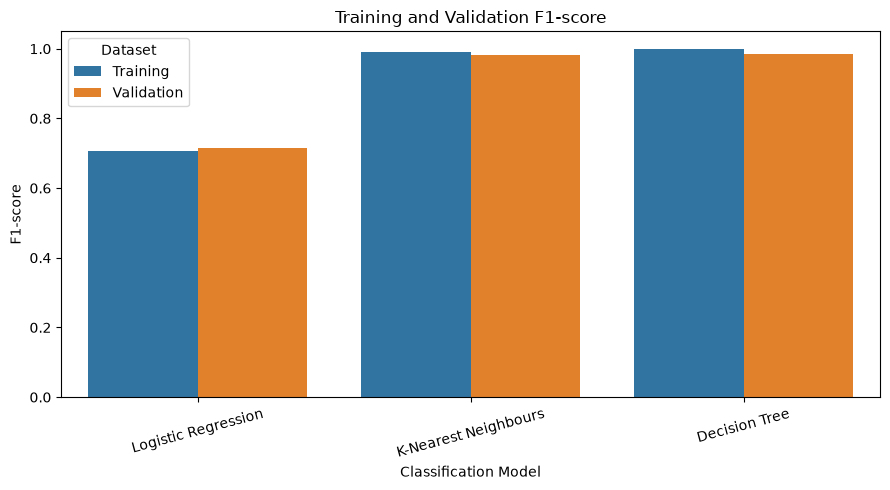

In [93]:
validation_f1 = (
    baseline_results_df[
        baseline_results_df["Dataset"] == "Validation"
    ]
    .sort_values("F1-score", ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="F1-score",
    hue="Dataset"
)

plt.title("Training and Validation F1-score")
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.xlabel("Classification Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [94]:
for model_name, model in trained_models.items():
    y_validation_pred = model.predict(X_validation)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_validation,
            y_validation_pred,
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0     0.8525    0.9048    0.8778      2037
           1     0.7685    0.6687    0.7152       963

    accuracy                         0.8290      3000
   macro avg     0.8105    0.7868    0.7965      3000
weighted avg     0.8255    0.8290    0.8256      3000

K-Nearest Neighbours
              precision    recall  f1-score   support

           0     0.9955    0.9872    0.9914      2037
           1     0.9735    0.9907    0.9820       963

    accuracy                         0.9883      3000
   macro avg     0.9845    0.9889    0.9867      3000
weighted avg     0.9885    0.9883    0.9884      3000

Decision Tree
              precision    recall  f1-score   support

           0     0.9941    0.9926    0.9934      2037
           1     0.9845    0.9875    0.9860       963

    accuracy                         0.9910      3000
   macro avg     0.9893    0.9901    0.9897      3000
weighted avg     0.

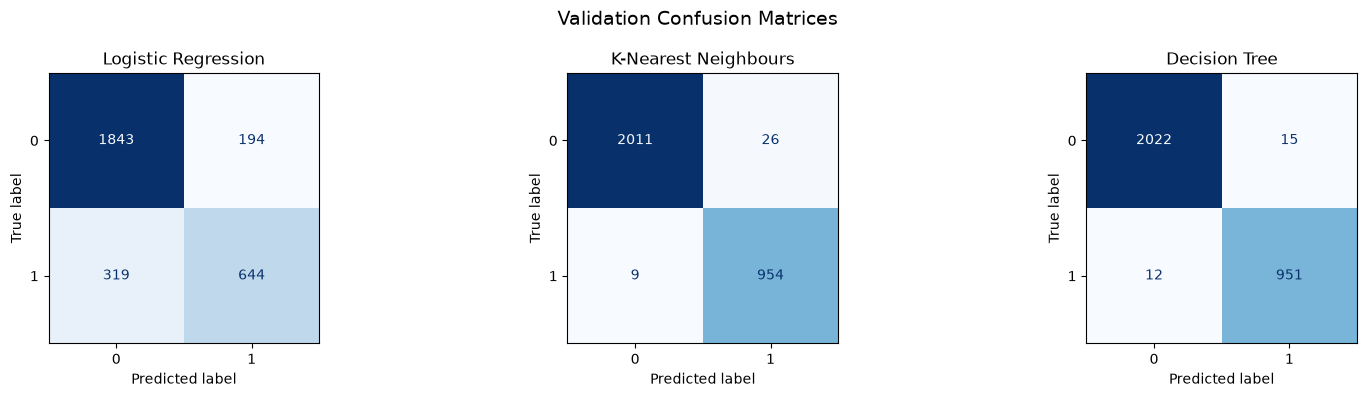

In [95]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4)
)

for axis, (model_name, model) in zip(
    axes,
    trained_models.items()
):
    y_validation_pred = model.predict(X_validation)

    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        y_validation_pred,
        cmap="Blues",
        colorbar=False,
        ax=axis
    )

    axis.set_title(model_name)

plt.suptitle(
    "Validation Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

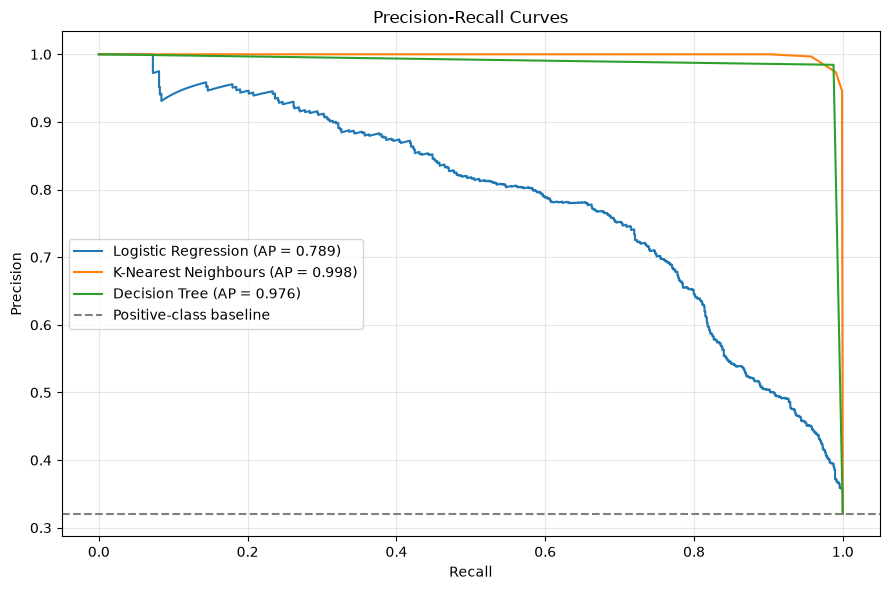

In [96]:
plt.figure(figsize=(9, 6))

for model_name, model in trained_models.items():
    y_validation_probability = model.predict_proba(
        X_validation
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_validation,
        y_validation_probability
    )

    average_precision = average_precision_score(
        y_validation,
        y_validation_probability
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{model_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.axhline(
    y=y_validation.mean(),
    color="grey",
    linestyle="--",
    label="Positive-class baseline"
)

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:
validation_results = baseline_results_df[
    baseline_results_df["Dataset"] == "Validation"
].copy()

validation_results = validation_results.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

validation_results.round(4)

,Model,Dataset,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,Validation,0.9910,0.9845,0.9875,0.9860,0.9901
1,K-Nearest Neighbours,Validation,0.9883,0.9735,0.9907,0.9820,0.9990
2,Logistic Regression,Validation,0.8290,0.7685,0.6687,0.7152,0.8730


In [98]:
best_baseline_model = validation_results.iloc[0]

print("Best baseline model:", best_baseline_model["Model"])
print(
    "Validation F1-score:",
    round(best_baseline_model["F1-score"], 4)
)

Best baseline model: Decision Tree
Validation F1-score: 0.986


In [99]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [100]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [101]:
logistic_parameter_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

In [102]:
knn_parameter_grid = {
    "classifier__n_neighbors": [
        3,
        5,
        7,
        9,
        11
    ],
    "classifier__weights": [
        "uniform",
        "distance"
    ],
    "classifier__p": [
        1,
        2
    ]
}

In [103]:
decision_tree_parameter_grid = {
    "classifier__criterion": [
        "gini",
        "entropy"
    ],
    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        5
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

In [104]:
parameter_grids = {
    "Logistic Regression": logistic_parameter_grid,
    "K-Nearest Neighbours": knn_parameter_grid,
    "Decision Tree": decision_tree_parameter_grid
}

In [106]:
grid_searches = {}
tuned_models = {}
tuning_results = []

for model_name, model_pipeline in models.items():
    print(f"Tuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=parameter_grids[model_name],
        scoring="f1",
        cv=cross_validation,
        n_jobs=-1,
        return_train_score=True,
        refit=True
    )

    grid_search.fit(X_train, y_train)

    grid_searches[model_name] = grid_search
    tuned_models[model_name] = grid_search.best_estimator_

    best_index = grid_search.best_index_

    validation_metrics = evaluate_model(
        grid_search.best_estimator_,
        X_validation,
        y_validation
    )

    tuning_results.append({
        "Model": model_name,
        "Best CV F1-score": grid_search.best_score_,
        "Mean CV Train F1-score":
            grid_search.cv_results_[
                "mean_train_score"
            ][best_index],
        "Validation Accuracy":
            validation_metrics["Accuracy"],
        "Validation Precision":
            validation_metrics["Precision"],
        "Validation Recall":
            validation_metrics["Recall"],
        "Validation F1-score":
            validation_metrics["F1-score"],
        "Validation ROC-AUC":
            validation_metrics["ROC-AUC"]
    })

    print("Best parameters:")
    print(grid_search.best_params_)
    print(
        "Best cross-validation F1-score:",
        round(grid_search.best_score_, 4)
    )

    print()

Tuning Logistic Regression...
Best parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}
Best cross-validation F1-score: 0.7178

Tuning K-Nearest Neighbours...
Best parameters:
{'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best cross-validation F1-score: 0.996

Tuning Decision Tree...
Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best cross-validation F1-score: 0.9873



In [107]:
for model_name, grid_search in grid_searches.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    for parameter, value in grid_search.best_params_.items():
        print(f"{parameter}: {value}")

    print(
        "Best CV F1-score:",
        round(grid_search.best_score_, 4)
    )

    print()

Logistic Regression
classifier__C: 0.01
classifier__class_weight: balanced
Best CV F1-score: 0.7178

K-Nearest Neighbours
classifier__n_neighbors: 3
classifier__p: 1
classifier__weights: distance
Best CV F1-score: 0.996

Decision Tree
classifier__class_weight: balanced
classifier__criterion: entropy
classifier__max_depth: None
classifier__min_samples_leaf: 1
classifier__min_samples_split: 2
Best CV F1-score: 0.9873



In [108]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Validation F1-score",
    ascending=False
).reset_index(drop=True)

tuning_results_df.round(4)

,Model,Best CV F1-score,Mean CV Train F1-score,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation ROC-AUC
0,K-Nearest Neighbours,0.9960,1.0000,0.9993,0.9990,0.9990,0.9990,1.0000
1,Decision Tree,0.9873,1.0000,0.9957,0.9927,0.9938,0.9933,0.9952
2,Logistic Regression,0.7178,0.7192,0.7973,0.6518,0.7913,0.7148,0.8701


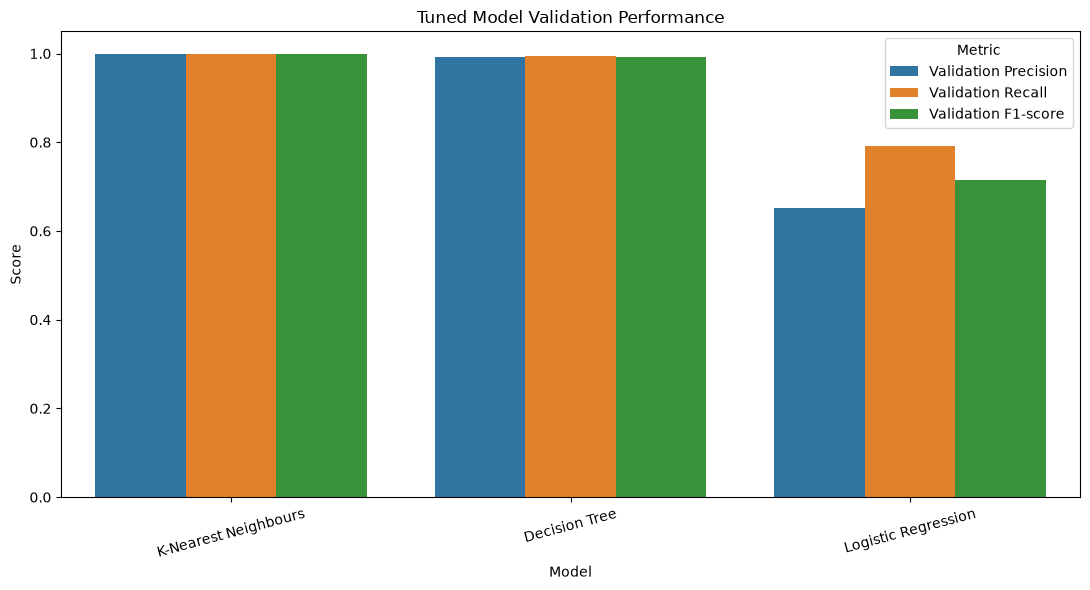

In [109]:
plot_data = tuning_results_df.melt(
    id_vars="Model",
    value_vars=[
        "Validation Precision",
        "Validation Recall",
        "Validation F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Tuned Model Validation Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [110]:
tuning_results_df["CV F1 Gap"] = (
    tuning_results_df["Mean CV Train F1-score"]
    - tuning_results_df["Best CV F1-score"]
)

tuning_results_df[
    [
        "Model",
        "Mean CV Train F1-score",
        "Best CV F1-score",
        "CV F1 Gap"
    ]
].round(4)

,Model,Mean CV Train F1-score,Best CV F1-score,CV F1 Gap
0,K-Nearest Neighbours,1.0000,0.9960,0.0040
1,Decision Tree,1.0000,0.9873,0.0127
2,Logistic Regression,0.7192,0.7178,0.0014


In [111]:
best_model_name = tuning_results_df.loc[
    0,
    "Model"
]

best_tuned_model = tuned_models[best_model_name]

print("Selected model:", best_model_name)
print(
    "Validation F1-score:",
    round(
        tuning_results_df.loc[
            0,
            "Validation F1-score"
        ],
        4
    )
)

Selected model: K-Nearest Neighbours
Validation F1-score: 0.999


In [112]:
#Examining the class distribution
class_counts = y_train.value_counts().sort_index()
class_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

class_balance_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_balance_df.round(2)

,Count,Percentage
Survive,,
0,6111,67.9
1,2889,32.1


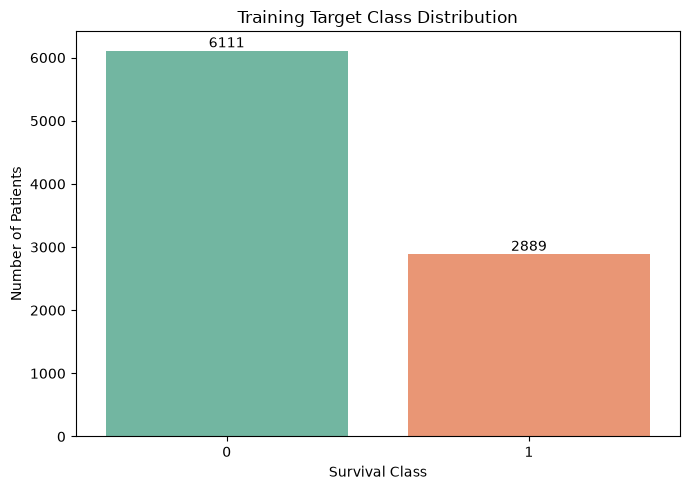

In [113]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x=y_train,
    hue=y_train,
    palette="Set2",
    legend=False
)

plt.title("Training Target Class Distribution")
plt.xlabel("Survival Class")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [114]:
#Calculating the imbalance ratio
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print(
    "Majority-to-minority ratio:",
    round(imbalance_ratio, 2)
)

Majority-to-minority ratio: 2.12


In [116]:
#establishing majority-class baseline

majority_baseline_accuracy = y_train.value_counts(
    normalize=True
).max()

print(
    "Majority-class baseline accuracy:",
    round(majority_baseline_accuracy, 4)
)

Majority-class baseline accuracy: 0.679


In [118]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbalancedPipeline

In [ ]:
#Configuring the resampling strategies
resampling_strategies = {
    "No Resampling": "passthrough",

    "Random Oversampling": RandomOverSampler(
        random_state=42
    ),

    "Random Undersampling": RandomUnderSampler(
        random_state=42
    )
}

In [120]:
resampling_results = []
resampling_models = {}

for strategy_name, sampler in resampling_strategies.items():
    resampling_pipeline = ImbalancedPipeline(steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "sampler",
            sampler
        ),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=3,
                weights="distance",
                p=1
            )
        )
    ])

    resampling_pipeline.fit(
        X_train,
        y_train
    )

    resampling_models[strategy_name] = (
        resampling_pipeline
    )

    validation_metrics = evaluate_model(
        resampling_pipeline,
        X_validation,
        y_validation
    )

    resampling_results.append({
        "Resampling Strategy": strategy_name,
        "Validation Accuracy":
            validation_metrics["Accuracy"],
        "Validation Precision":
            validation_metrics["Precision"],
        "Validation Recall":
            validation_metrics["Recall"],
        "Validation F1-score":
            validation_metrics["F1-score"],
        "Validation ROC-AUC":
            validation_metrics["ROC-AUC"]
    })

In [121]:
resampling_results_df = pd.DataFrame(
    resampling_results
)

resampling_results_df = (
    resampling_results_df
    .sort_values(
        by="Validation F1-score",
        ascending=False
    )
    .reset_index(drop=True)
)

resampling_results_df.round(4)

,Resampling Strategy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation ROC-AUC
0,Random Oversampling,0.9997,0.9990,1.000,0.9995,1.0000
1,No Resampling,0.9993,0.9990,0.999,0.9990,1.0000
2,Random Undersampling,0.9957,0.9867,1.000,0.9933,0.9997


In [122]:
#using cross validation

from sklearn.model_selection import cross_validate

cross_validation_results = []

for strategy_name, model in resampling_models.items():
    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        cv=cross_validation,
        n_jobs=-1,
        return_train_score=False
    )

    cross_validation_results.append({
        "Resampling Strategy": strategy_name,
        "Mean CV Accuracy":
            scores["test_accuracy"].mean(),
        "Mean CV Precision":
            scores["test_precision"].mean(),
        "Mean CV Recall":
            scores["test_recall"].mean(),
        "Mean CV F1-score":
            scores["test_f1"].mean(),
        "Mean CV ROC-AUC":
            scores["test_roc_auc"].mean()
    })

In [123]:
resampling_cv_df = pd.DataFrame(
    cross_validation_results
)

resampling_cv_df = resampling_cv_df.sort_values(
    by="Mean CV F1-score",
    ascending=False
).reset_index(drop=True)

resampling_cv_df.round(4)

,Resampling Strategy,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV F1-score,Mean CV ROC-AUC
0,No Resampling,0.9974,0.9959,0.9962,0.9960,0.9995
1,Random Oversampling,0.9968,0.9918,0.9983,0.9950,0.9990
2,Random Undersampling,0.9894,0.9689,0.9993,0.9838,0.9988


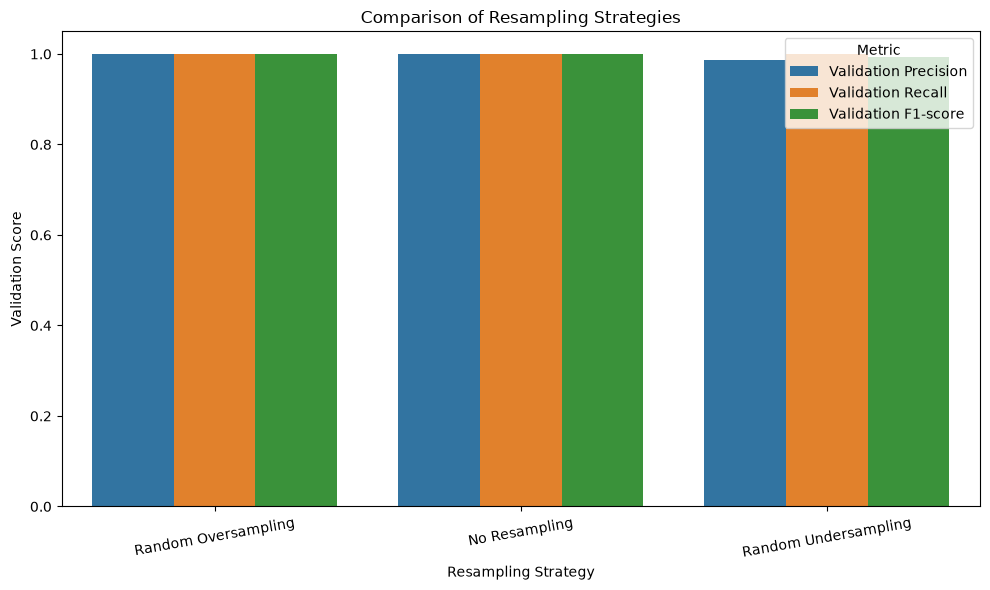

In [124]:
resampling_plot_data = resampling_results_df.melt(
    id_vars="Resampling Strategy",
    value_vars=[
        "Validation Precision",
        "Validation Recall",
        "Validation F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=resampling_plot_data,
    x="Resampling Strategy",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Resampling Strategies")
plt.xlabel("Resampling Strategy")
plt.ylabel("Validation Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

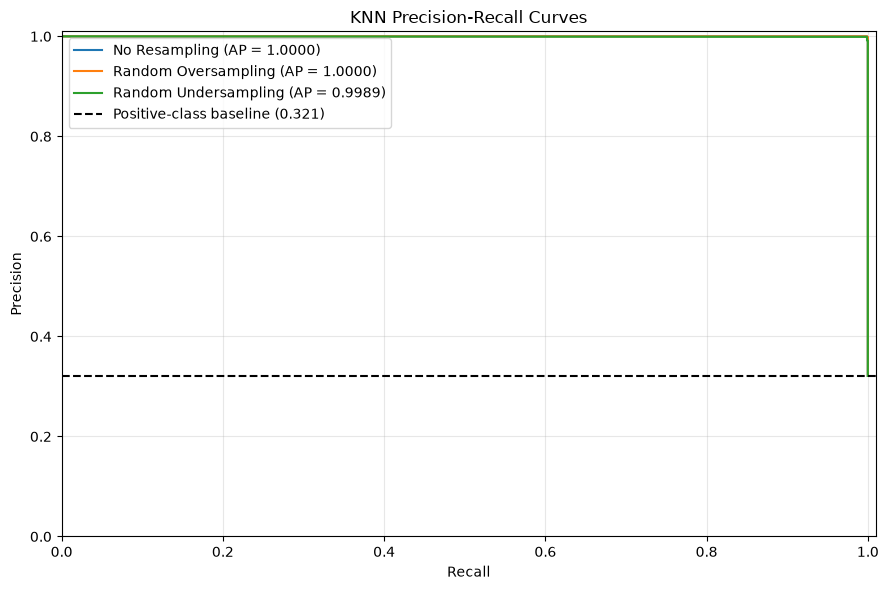

In [126]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(9, 6))

for strategy_name, model in resampling_models.items():
    validation_probability = model.predict_proba(
        X_validation
    )[:, 1]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_validation,
            validation_probability
        )
    )

    average_precision = average_precision_score(
        y_validation,
        validation_probability
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{strategy_name} "
            f"(AP = {average_precision:.4f})"
        )
    )

positive_class_baseline = y_validation.mean()

plt.axhline(
    y=positive_class_baseline,
    color="black",
    linestyle="--",
    label=(
        "Positive-class baseline "
        f"({positive_class_baseline:.3f})"
    )
)

plt.title("KNN Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [127]:
best_resampling_strategy = (
    resampling_results_df.loc[
        0,
        "Resampling Strategy"
    ]
)

best_resampled_model = resampling_models[
    best_resampling_strategy
]

print(
    "Best resampling strategy:",
    best_resampling_strategy
)

Best resampling strategy: Random Oversampling


Conclusion: The dataset do not have such a drastic imbalance. It has class 0 which occur about 2.12 times more than class 1. I used random oversampling and random undersampling were being compared against the original training distribution. The last attempt was to use cross validation and validation F1-score. 

In [128]:
resampling_results_df.round(4)

,Resampling Strategy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation ROC-AUC
0,Random Oversampling,0.9997,0.9990,1.000,0.9995,1.0000
1,No Resampling,0.9993,0.9990,0.999,0.9990,1.0000
2,Random Undersampling,0.9957,0.9867,1.000,0.9933,0.9997


In [129]:
resampling_cv_df.round(4)

,Resampling Strategy,Mean CV Accuracy,Mean CV Precision,Mean CV Recall,Mean CV F1-score,Mean CV ROC-AUC
0,No Resampling,0.9974,0.9959,0.9962,0.9960,0.9995
1,Random Oversampling,0.9968,0.9918,0.9983,0.9950,0.9990
2,Random Undersampling,0.9894,0.9689,0.9993,0.9838,0.9988


In [130]:
best_resampling_strategy = (
    resampling_results_df
    .sort_values(
        by="Validation F1-score",
        ascending=False
    )
    .iloc[0]["Resampling Strategy"]
)

print(
    "Selected resampling strategy:",
    best_resampling_strategy
)

Selected resampling strategy: Random Oversampling


In [131]:
tuned_knn_pipeline = tuned_models[
    "K-Nearest Neighbours"
]

tuned_knn_classifier = clone(
    tuned_knn_pipeline.named_steps[
        "classifier"
    ]
)

print(tuned_knn_classifier)

KNeighborsClassifier(n_neighbors=3, p=1, weights='distance')


In [132]:
if best_resampling_strategy == "Random Oversampling":
    final_sampler = RandomOverSampler(
        random_state=42
    )

elif best_resampling_strategy == "Random Undersampling":
    final_sampler = RandomUnderSampler(
        random_state=42
    )

else:
    final_sampler = "passthrough"

In [133]:
final_pipeline = ImbalancedPipeline(steps=[
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "sampler",
        final_sampler
    ),
    (
        "classifier",
        tuned_knn_classifier
    )
])

final_pipeline

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string r

In [134]:
X_development = pd.concat(
    [
        X_train,
        X_validation
    ],
    axis=0
)

y_development = pd.concat(
    [
        y_train,
        y_validation
    ],
    axis=0
)

In [135]:
X_development = X_development.reset_index(
    drop=True
)

y_development = y_development.reset_index(
    drop=True
)

In [136]:
print(
    "Development feature shape:",
    X_development.shape
)

print(
    "Development target shape:",
    y_development.shape
)

print(
    "Test feature shape:",
    X_test.shape
)

print(
    "Test target shape:",
    y_test.shape
)

Development feature shape: (12000, 13)
Development target shape: (12000,)
Test feature shape: (3000, 13)
Test target shape: (3000,)


In [137]:
final_pipeline.fit(
    X_development,
    y_development
)

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['Gender','Smoke','Diabetes',...,'Hemoglobin','Height','Weight']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [138]:
final_test_metrics = evaluate_model(
    final_pipeline,
    X_test,
    y_test
)

final_test_results_df = pd.DataFrame([
    {
        "Model": "Tuned K-Nearest Neighbours",
        "Resampling Strategy":
            best_resampling_strategy,
        **final_test_metrics
    }
])

final_test_results_df.round(4)

,Model,Resampling Strategy,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned K-Nearest Neighbours,Random Oversampling,0.999,0.9969,1.0,0.9984,1.0


In [139]:
y_test_pred = final_pipeline.predict(
    X_test
)

y_test_probability = final_pipeline.predict_proba(
    X_test
)[:, 1]

In [140]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.9985    0.9993      2037
           1     0.9969    1.0000    0.9984       963

    accuracy                         0.9990      3000
   macro avg     0.9984    0.9993    0.9989      3000
weighted avg     0.9990    0.9990    0.9990      3000



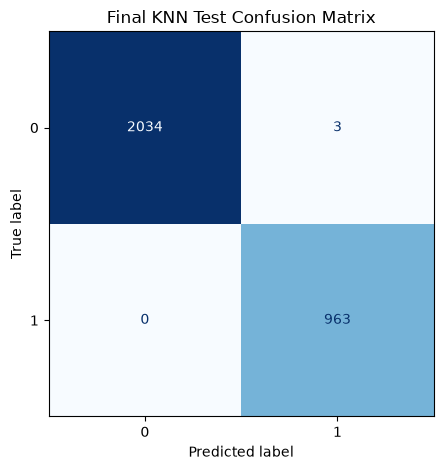

In [141]:
#Final confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Final KNN Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [142]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix(
        y_test,
        y_test_pred
    ).ravel()
)

print("True negatives:", true_negative)
print("False positives:", false_positive)
print("False negatives:", false_negative)
print("True positives:", true_positive)

True negatives: 2034
False positives: 3
False negatives: 0
True positives: 963


In [143]:
final_precision, final_recall, final_thresholds = (
    precision_recall_curve(
        y_test,
        y_test_probability
    )
)

final_average_precision = average_precision_score(
    y_test,
    y_test_probability
)

positive_class_baseline = y_test.mean()

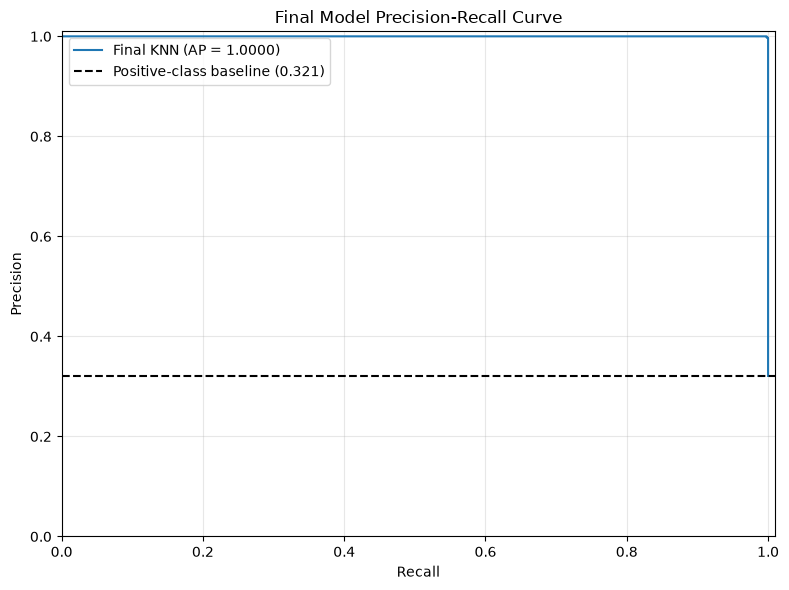

In [144]:
plt.figure(figsize=(8, 6))

plt.plot(
    final_recall,
    final_precision,
    label=(
        "Final KNN "
        f"(AP = {final_average_precision:.4f})"
    )
)

plt.axhline(
    y=positive_class_baseline,
    color="black",
    linestyle="--",
    label=(
        "Positive-class baseline "
        f"({positive_class_baseline:.3f})"
    )
)

plt.title(
    "Final Model Precision-Recall Curve"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [145]:
final_comparison = pd.DataFrame([
    {
        "Stage": "Baseline",
        "Dataset": "Validation",
        "Model": "K-Nearest Neighbours",
        "F1-score": baseline_results_df.loc[
            (
                baseline_results_df["Model"]
                == "K-Nearest Neighbours"
            )
            & (
                baseline_results_df["Dataset"]
                == "Validation"
            ),
            "F1-score"
        ].iloc[0]
    },
    {
        "Stage": "Tuned",
        "Dataset": "Validation",
        "Model": "K-Nearest Neighbours",
        "F1-score": tuning_results_df.loc[
            tuning_results_df["Model"]
            == "K-Nearest Neighbours",
            "Validation F1-score"
        ].iloc[0]
    },
    {
        "Stage": "Final",
        "Dataset": "Test",
        "Model": "K-Nearest Neighbours",
        "F1-score": final_test_metrics[
            "F1-score"
        ]
    }
])

final_comparison.round(4)

,Stage,Dataset,Model,F1-score
0,Baseline,Validation,K-Nearest Neighbours,0.9820
1,Tuned,Validation,K-Nearest Neighbours,0.9990
2,Final,Test,K-Nearest Neighbours,0.9984


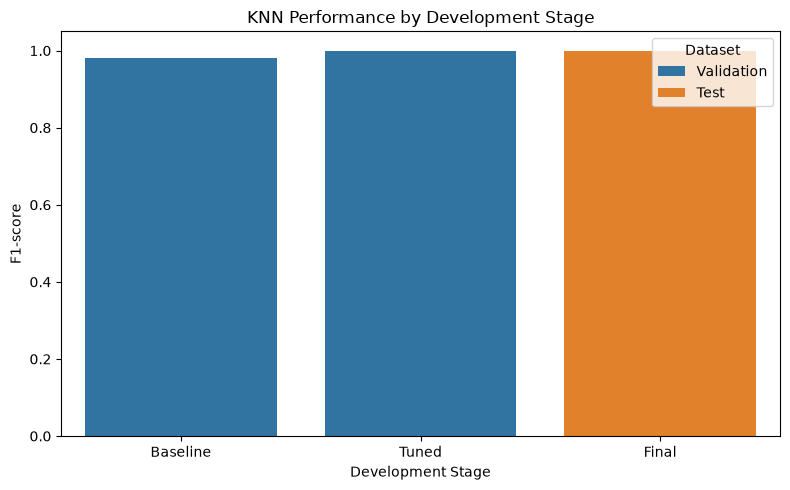

In [146]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=final_comparison,
    x="Stage",
    y="F1-score",
    hue="Dataset"
)

plt.title("KNN Performance by Development Stage")
plt.xlabel("Development Stage")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

Overall concluion: I have used Logistic Regression, K-Nearest Neighbours and Decision Tree were used to evaluate the patient survival. The models are compared  using accuracy, precision, recall, F1-score and ROC_AUC because the dataset has a moderate class imbalance. Hyperparameter tuning was alone done using the stratified five-fold cross-validation, with F1-score as the optimisation metrics.

The tuned KNN model obtained the strongest validation performance. The final pipeline was retrained again using the combined training and validation data and was evaluated once on a new test set. Based on the results shown above, KNN is selected to be the best model.